#03 - Multi-dataset model comparison
- Trains best model (Random Forest + RUL Capping) on all 4 datasets
- Compares performance across FD001 - FD004
- Analyzes why performance differs across datasets
- draws conclusion about model robustness

In [2]:
import pandas as pd 
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings 
warnings.filterwarnings('ignore')


In [3]:
#defining column names 

columns = ['engine_id', 'cycle', 'op1','op2', 'op3'] + [f's{i}' for i in range(1,22)]

#loading all datasets 
datasets = {}
for i in range(1,5):
    train = pd.read_csv(f'../data/raw/train_FD00{i}.txt', sep='\s+', header = None, names=columns)
    test = pd.read_csv(f'../data/raw/test_FD00{i}.txt', sep='\s+', header = None, names = columns)
    rul = pd.read_csv(f'../data/raw/RUL_FD00{i}.txt', sep='\s+', header = None, names = ['RUL'])

    datasets[f'FD00{i}'] = {'train': train, 'test': test, 'rul': rul}
    print(f"FD00{i} loaded - Train shape: {train.shape}")

FD001 loaded - Train shape: (20631, 26)
FD002 loaded - Train shape: (53759, 26)
FD003 loaded - Train shape: (24720, 26)
FD004 loaded - Train shape: (61249, 26)


In [4]:
def process_dataset(train, flat_sensors = None, cap = 125, window = 5):
    """
    Complete pipeline:
    1. Calculate RUL
    2. Drop flat sensors
    3. Add rolling features 
    4. Normalize
    5. Cap RUL
    """
    #calculating RUL
    max_cycles = train.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    train = train.merge(max_cycles, on = 'engine_id')
    train['RUL'] = train['max_cycle'] - train['cycle']
    train.drop(columns=['max_cycle'], inplace=True)

    #Dropping flat sensors
    if flat_sensors is None:
        flat_sensors = ['s1', 's5','s6','s10','s16', 's18', 's19', 'op3']
    train = train.drop(columns=flat_sensors, errors ='ignore')

    #rolling features 

    sensors = [c for c in train.columns if c.startswith('s') and '_roll' not in c]


    for sensor in sensors:
        train[f'{sensor}_rollmean'] = train.groupby('engine_id')[sensor].transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        train[f'{sensor}_rollstd'] = train.groupby('engine_id')[sensor].transform(lambda x : x.rolling(window=window, min_periods=1).std().fillna(0))

    #Normalize
    feature_cols = [ c for c in train.columns if c not in ['engine_id', 'cycle', 'RUL']]
    scaler = MinMaxScaler()
    train[feature_cols] = scaler.fit_transform(train[feature_cols])

    #Cap RUL
    train['RUL'] = train['RUL'].clip(upper= cap)

    return train, scaler 
 


In [5]:
def train_evaluate(train_df, dataset_name): 
    """
    Train best Random Forest model and evaluate
    returns performance metrics
    """
    #Prepare features and target
    X = train_df.drop(columns=['engine_id', 'cycle','RUL'])
    y = train_df['RUL']

    #Train test split
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state=42)

    #train random forest
    model = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=1, min_samples_split=2, random_state=42, n_jobs=-1)

    model.fit(X_train, y_train)

    #evaluate
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    print(f"\n{dataset_name} Results:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.4f}")

    return{'dataset': dataset_name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'model': model, 'predictions': pred, 'actuals': y_test}



In [6]:
#processing and training on all datasets
results = {}

for name, data, in datasets.items():
    print(f"\nProcessing {name}...")
    
    #process dataset
    processed, scaler = process_dataset(data['train'])

    #Train and evaluate
    result = train_evaluate(processed, name)
    results[name] = result

print("\n\nAll datasets processed!")


Processing FD001...

FD001 Results:
RMSE: 15.51
MAE: 10.89
R2: 0.8581

Processing FD002...

FD002 Results:
RMSE: 20.03
MAE: 15.11
R2: 0.7673

Processing FD003...

FD003 Results:
RMSE: 13.43
MAE: 8.86
R2: 0.8893

Processing FD004...

FD004 Results:
RMSE: 18.15
MAE: 12.88
R2: 0.8010


All datasets processed!


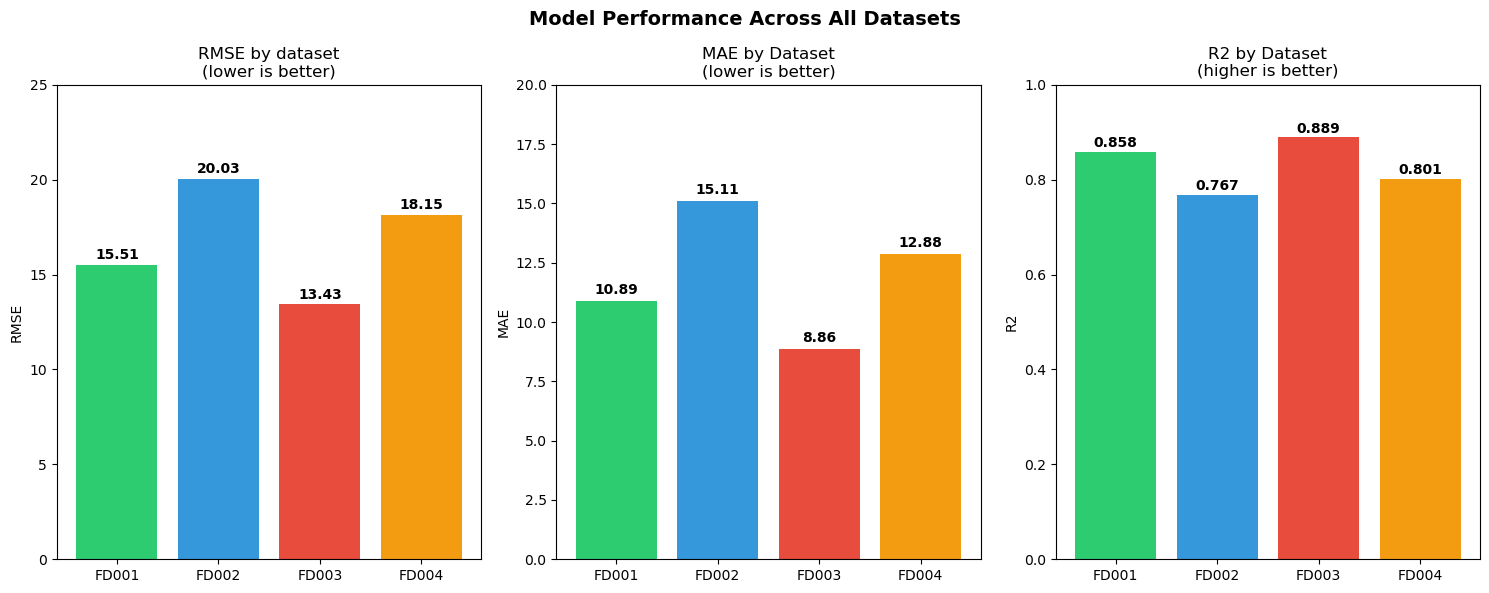

In [7]:
fig, axes = plt.subplots(1,3, figsize=(15,6))

dataset_names = list(results.keys())
rmse_scores = [results[d]['rmse'] for d in dataset_names]
mae_scores = [results[d]['mae'] for d in dataset_names]
r2_scores = [results[d]['r2'] for d in dataset_names]

colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

#RMSE 
bars1 = axes[0].bar(dataset_names, rmse_scores, color=colors)
axes[0].set_title('RMSE by dataset\n(lower is better)', fontsize=12)
axes[0].set_ylabel('RMSE')
axes[0].set_ylim(0,25)
for bar, val in zip(bars1, rmse_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.2f}', ha='center', fontweight='bold')

#MAE
bars2 = axes[1].bar(dataset_names, mae_scores, color= colors)
axes[1].set_title('MAE by Dataset\n(lower is better)', fontsize=12)
axes[1].set_ylabel('MAE')
axes[1].set_ylim(0,20)
for bar, val in zip(bars2, mae_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.2f}', ha = 'center', fontweight='bold')

#r2
bars3 = axes[2].bar(dataset_names, r2_scores, color=colors)
axes[2].set_title('R2 by Dataset\n(higher is better)', fontsize=12)
axes[2].set_ylabel('R2')
axes[2].set_ylim(0,1)
for bar, val in zip(bars3, r2_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Across All Datasets', fontsize = 14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/multi_dataset_comparison.png', dpi=150)
plt.show()


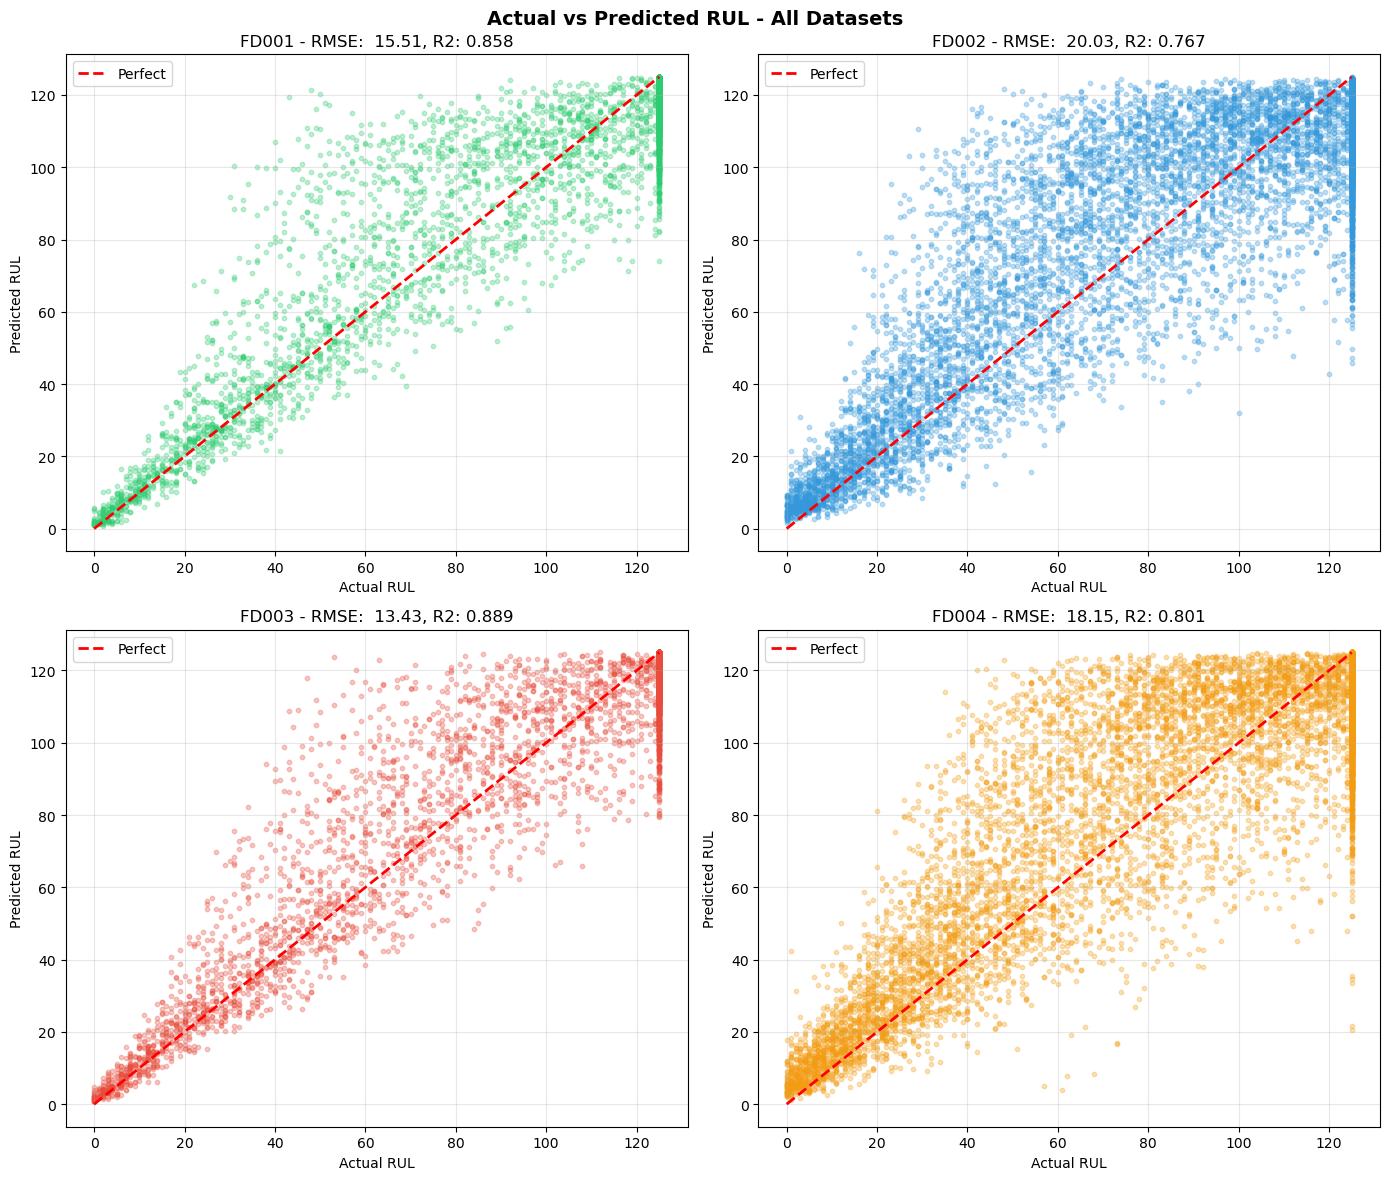

In [8]:
#actual vs predicted for all datasets

fig, axes = plt.subplots(2, 2, figsize = (14,12))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    actuals = result['actuals']
    preds = result['predictions']

    axes[idx].scatter(actuals, preds, alpha=0.3, color = colors[idx], s=10)

    max_val = max(actuals.max(), preds.max())
    axes[idx].plot([0, max_val], [0,max_val], 'r--', linewidth=2,label='Perfect')

    axes[idx].set_xlabel('Actual RUL')
    axes[idx].set_ylabel('Predicted RUL')
    axes[idx].set_title(f'{name} - RMSE: {result["rmse"]: .2f}, R2: {result["r2"]:.3f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted RUL - All Datasets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/all_datasets_predictions.png', dpi =150)
plt.show()


In [9]:
#saving FD001 model 
fd001_train_save = datasets['FD001']['train'].copy()
fd001_processed_save, fd001_scaler_save = process_dataset(fd001_train_save)

# Get exact feature columns in exact order
fd001_feature_cols = [c for c in fd001_processed_save.columns 
                      if c not in ['engine_id', 'cycle', 'RUL']]

print("Feature columns in order:")
print(fd001_feature_cols)
print(f"\nTotal features: {len(fd001_feature_cols)}")

# Save model
with open('../outputs/models/rf_fd001_capped.pkl', 'wb') as f:
    pickle.dump(results['FD001']['model'], f)

# Save feature columns
with open('../outputs/models/feature_cols.pkl', 'wb') as f:
    pickle.dump(fd001_feature_cols, f)

print("\nModel and feature columns saved!")

Feature columns in order:
['op1', 'op2', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 's2_rollmean', 's2_rollstd', 's3_rollmean', 's3_rollstd', 's4_rollmean', 's4_rollstd', 's7_rollmean', 's7_rollstd', 's8_rollmean', 's8_rollstd', 's9_rollmean', 's9_rollstd', 's11_rollmean', 's11_rollstd', 's12_rollmean', 's12_rollstd', 's13_rollmean', 's13_rollstd', 's14_rollmean', 's14_rollstd', 's15_rollmean', 's15_rollstd', 's17_rollmean', 's17_rollstd', 's20_rollmean', 's20_rollstd', 's21_rollmean', 's21_rollstd']

Total features: 44

Model and feature columns saved!


In [ ]:
# Health status function
def health_status_label(rul):
    if rul <= 30:
        return 'CRITICAL'
    elif rul <= 60:
        return 'WARNING'
    elif rul <= 90:
        return 'MONITOR'
    else:
        return 'HEALTHY'

# Operating condition descriptions
condition_map = {
    'FD001': '1 Condition, 1 Fault (HPC)',
    'FD002': '6 Conditions, 1 Fault (HPC)',
    'FD003': '1 Condition, 2 Faults (HPC+Fan)',
    'FD004': '6 Conditions, 2 Faults (HPC+Fan)'
}

# Build tableau export using already loaded datasets dict
tableau_frames = []

for name, data in datasets.items():
    # Use unique variable name to avoid conflicts
    tableau_train = data['train'].copy()
    
    # Add dataset identifier
    tableau_train['dataset'] = name
    tableau_train['dataset_desc'] = condition_map[name]
    
    # Calculate RUL
    max_cycles = tableau_train.groupby('engine_id')['cycle']\
                 .max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    tableau_train = tableau_train.merge(max_cycles, on='engine_id')
    tableau_train['RUL'] = tableau_train['max_cycle'] - \
                           tableau_train['cycle']
    tableau_train.drop(columns=['max_cycle'], inplace=True)
    
    # Add health status
    tableau_train['health_status'] = tableau_train['RUL']\
                                     .apply(health_status_label)
    
    tableau_frames.append(tableau_train)
    print(f"{name} prepared ✅ — {tableau_train.shape[0]:,} rows")

# Combine all datasets
tableau_all = pd.concat(tableau_frames, ignore_index=True)

# Export
tableau_all.to_csv('../data/processed/tableau_all_datasets.csv',
                   index=False)

print(f"\nTotal rows: {tableau_all.shape[0]:,}")
print(f"Total columns: {tableau_all.shape[1]}")
print(f"\nHealth status distribution:")
print(tableau_all['health_status'].value_counts())
print(f"\nDataset distribution:")
print(tableau_all['dataset'].value_counts())
print("\nExported for Tableau!")

FD001 prepared ✅ — 20,631 rows
FD002 prepared ✅ — 53,759 rows
FD003 prepared ✅ — 24,720 rows
FD004 prepared ✅ — 61,249 rows

Total rows: 160,359
Total columns: 30

Health status distribution:
health_status
HEALTHY     95840
CRITICAL    21979
MONITOR     21270
WARNING     21270
Name: count, dtype: int64

Dataset distribution:
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64

Exported for Tableau!
